<a href="https://colab.research.google.com/github/rakshitaggarwal/Simple-Linear-Regression/blob/main/Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv('height-weight.csv')
df.head(6)

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162


Text(0.5, 1.0, 'Height vs Weight')

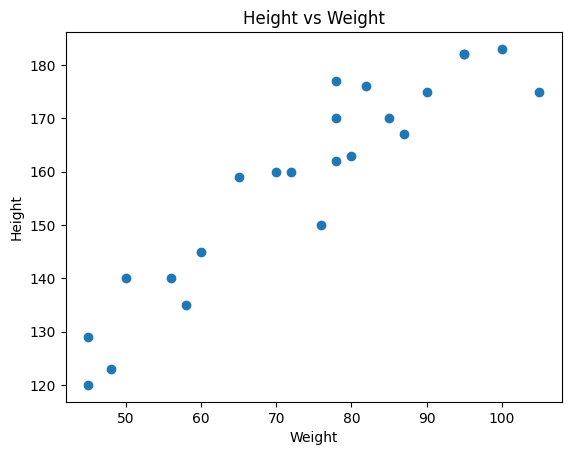

In [3]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Height vs Weight')

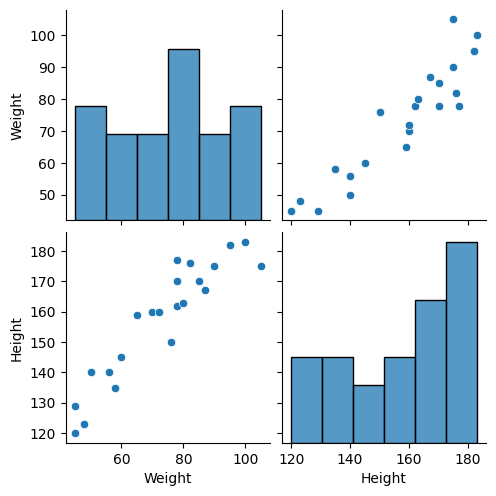

In [4]:
sns.pairplot(df)

In [5]:
##correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [6]:
## Independent and dependent features
x=df[['Weight']] ### independent features should be data frame or 2 dimesnionalarray
y=df['Height'] ## this variiable can be in series or 1d array


In [7]:
##Train test split
from sklearn.model_selection import train_test_split


In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [9]:
x_train.shape

(17, 1)

In [10]:
##standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [11]:
x_test=scaler.transform(x_test)
x_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

**Apply Simple Linear Regression**

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
regression=LinearRegression(n_jobs=-1)

In [14]:
regression.fit(x_train,y_train) ##if we will be having input x_train as series then here it will give an error

LinearRegression(n_jobs=-1)

In [15]:
print("Coefficient or slope: ",regression.coef_)
print("Intercept: ",regression.intercept_)

Coefficient or slope:  [17.2982057]
Intercept:  156.47058823529412


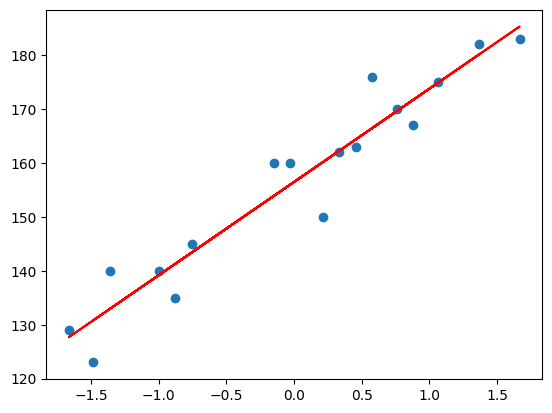

In [16]:
##plot training data
##plotting best fit line
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train),color='red')

**prediction of test data**


*   predicted height output=intercept+coef_(weights)
*   y_pred_test=156.47+17.29(x_test)



In [17]:
##prediction for test data
y_pred=regression.predict(x_test)

In [18]:
##Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [19]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean Absolute Error:",mae)
print("Mean Square Error:",mse)
print("Root Mean Square Error:",rmse)

Mean Absolute Error: 9.66512588679501
Mean Square Error: 114.84069295228699
Root Mean Square Error: 10.716374991212605


r2 formula =1-SSR/SST

In [20]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7360826717981276

**OLS Linear Regression**

In [21]:
import statsmodels.api as sm


In [22]:
model=sm.OLS(y_train,x_train).fit()

In [23]:
prediction=model.predict(x_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [24]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 16 Aug 2025   Prob (F-statistic):                       0.664
Time:                        19:46:12   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [25]:
##prediction for new data
regression.predict(scaler.transform([[80]]))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([164.36084726])